# Phase 4 — Baseline Predictive Model
**InterveneAI · Logistic Regression baseline for `purchased_next_60_days`**

Trained by `src/models/train_baseline.py` (pipeline + metrics saved under
`models/`). This notebook independently verifies the saved artifacts against
the data, then evaluates: chronological splits, PR/ROC curves, thresholds,
confusion matrices, precision@k/lift and calibration. Accuracy is never used
as a decision metric. No advanced models are built here.

## Framing (explained fully at the end, after the numbers)
- **Chronological split, not random**: train 2017-04–2017-12, validation
  2018-01–2018-03, test 2018-04–2018-06. A model deployed at end of March 2018
  can only have seen data up to then — the split reproduces that constraint.
- **PR-AUC is primary**: at ~0.5% prevalence, ROC-AUC is dominated by the
  correctly-ranked negatives; precision–recall exposes what rare-event
  ranking actually costs.
- **Imbalance handling**: `class_weight="balanced"` (no resampling, nothing
  synthetic). Known cost: it distorts predicted probabilities — checked in
  the calibration section rather than assumed away.

In [1]:
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format
SEED = 42

def find(base):
    cands = [Path(base), Path("../") / base]
    return next(p for p in cands if p.exists())

df = pd.read_parquet(find("data/processed/customer_features_v3.parquet"))
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
bundle = joblib.load(find("models/baseline_pipeline.pkl"))
pipe, FEATURES = bundle["pipeline"], bundle["features"]
TARGET = bundle["target"]
with open(find("models/baseline_metrics.json")) as f:
    saved = json.load(f)
TRAIN_END = pd.Timestamp(saved["train_end"])
VAL_END = pd.Timestamp(saved["val_end"])
print("pipeline steps:", [s for s, _ in pipe.steps])
print("features:", len(FEATURES), "| target:", TARGET, "| seed:", bundle["seed"])

pipeline steps: ['impute', 'scale', 'clf']
features: 10 | target: purchased_next_60_days | seed: 42


## 1. Chronological splits — exact date ranges
Periods are cut on snapshot months with no shuffling. Imputer/scaler were fit
on train only; the F1 threshold was picked on validation; test is reported once.
Printed ranges below come from the data, not from memory.

In [2]:
train = df[df["snapshot_date"] <= TRAIN_END]
val = df[(df["snapshot_date"] > TRAIN_END) & (df["snapshot_date"] <= VAL_END)]
test = df[df["snapshot_date"] > VAL_END]
assert train["snapshot_date"].max() < val["snapshot_date"].min()
assert val["snapshot_date"].max() < test["snapshot_date"].min()
for name, part in [("train", train), ("val", val), ("test", test)]:
    r = part[TARGET].mean()
    print(name, str(part["snapshot_date"].min().date()), "to",
          str(part["snapshot_date"].max().date()),
          "| rows", len(part), "| positives", int(part[TARGET].sum()),
          "| rate", str(round(100 * r, 4)) + "%")
    js = saved["splits"][name]
    assert js["rows"] == len(part) and js["positives"] == int(part[TARGET].sum())
print("split counts match saved metrics JSON")
overlap = set(test["customer_unique_id"]) & set(train["customer_unique_id"])
print("test customers also seen in train:", len(overlap), "of",
      test["customer_unique_id"].nunique(),
      "(stacked panel: periods disjoint, customers may repeat — disclosed)")

train 2017-04-01 to 2017-12-01 | rows 140605 | positives 943 | rate 0.6707%
val 2018-01-01 to 2018-03-01 | rows 93774 | positives 522 | rate 0.5567%
test 2018-04-01 to 2018-06-01 | rows 114388 | positives 620 | rate 0.542%
split counts match saved metrics JSON


test customers also seen in train: 11631 of 49961 (stacked panel: periods disjoint, customers may repeat — disclosed)


## 2. Model and imbalance handling
Median imputation (gap features are NaN for ~97% of rows) → standardisation →
logistic regression with `class_weight="balanced"`. Coefficients below are on
standardised features, hence comparable in magnitude; signs are associational
(a marker of who repurchases, not a lever). C = 1.0, no tuning — tuning is a
later phase.

avg_order_value_180d           -0.535965
avg_days_between_orders        -0.148036
recency_days                   -0.076787
purchase_velocity_90d          -0.013789
purchase_count_90d             -0.013789
purchase_count_30d              0.094729
purchase_velocity_30d           0.094729
purchase_count_180d             0.103915
days_since_previous_purchase    0.238928
total_spend_180d                0.510809
intercept: -0.0748


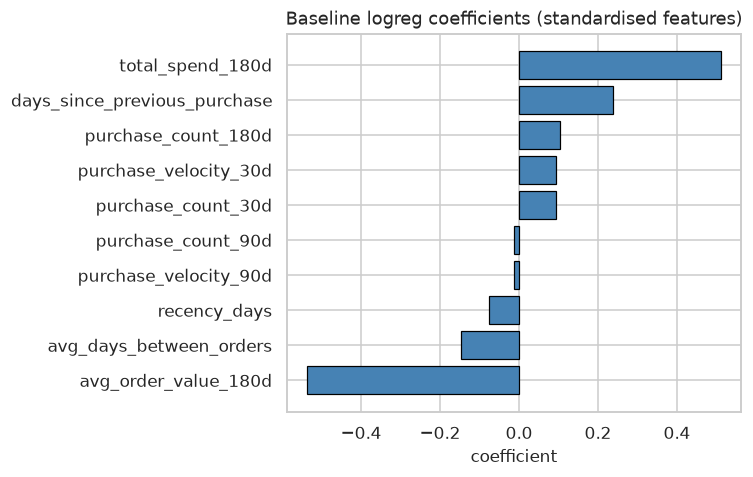

In [3]:
coefs = pd.Series(saved["coefficients"]).sort_values()
print(coefs.to_string())
print("intercept:", round(saved["intercept"], 4))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(coefs.index, coefs.values, color="steelblue", edgecolor="black", linewidth=0.8)
ax.set_title("Baseline logreg coefficients (standardised features)")
ax.set_xlabel("coefficient")
plt.tight_layout()
plt.show()

## 3. Ranking metrics — PR-AUC (primary) and ROC-AUC
Scores are recomputed here from the saved pipeline and asserted equal to the
saved JSON, so every number below is verified, not copied. Dashed lines are
the random-ranking reference (PR-AUC = prevalence, ROC-AUC = 0.5).

val pr_auc = 0.0206 | saved 0.0206 | match
val roc_auc = 0.5972 | saved 0.5972 | match
val brier = 0.2319 | saved 0.2319 | match
test pr_auc = 0.0126 | saved 0.0126 | match
test roc_auc = 0.625 | saved 0.625 | match
test brier = 0.2279 | saved 0.2279 | match
test prevalence (random PR-AUC): 0.0054


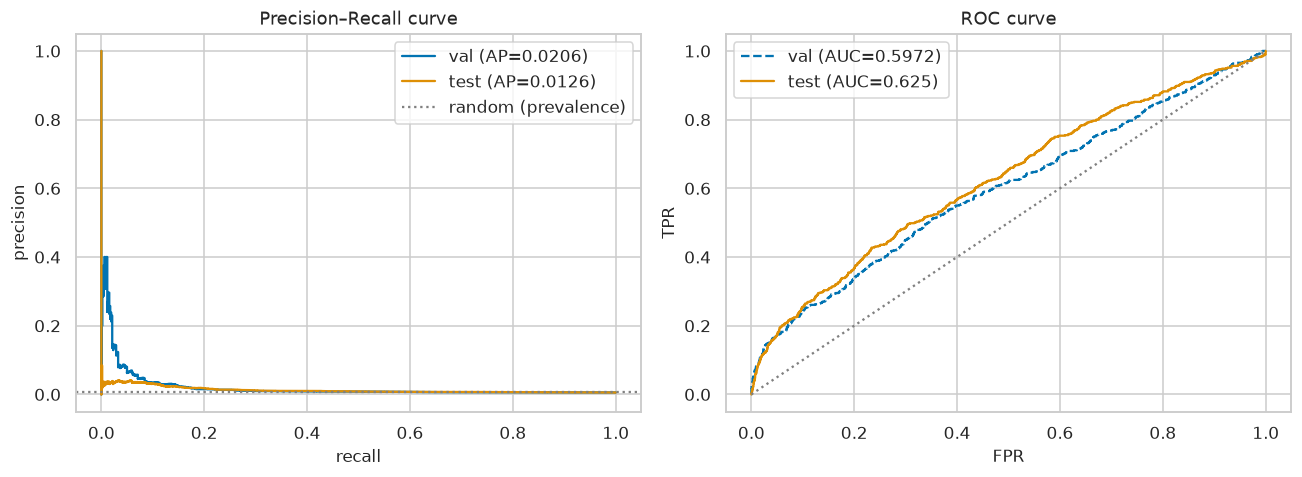

In [4]:
scores = {}
for name, part in [("val", val), ("test", test)]:
    s = pipe.predict_proba(part[FEATURES])[:, 1]
    scores[name] = (np.asarray(part[TARGET]), s)
    for m, fn in [("pr_auc", average_precision_score), ("roc_auc", roc_auc_score),
                  ("brier", brier_score_loss)]:
        got, exp = float(fn(scores[name][0], s)), saved[name][m]
        assert abs(got - exp) < 1e-9, (name, m, got, exp)
        print(name, m, "=", round(got, 4), "| saved", round(exp, 4), "| match")
print("test prevalence (random PR-AUC):", round(scores["test"][0].mean(), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, ls in [("val", "--"), ("test", "-")]:
    yy, ss = scores[name]
    p, r, _ = precision_recall_curve(yy, ss)
    axes[0].step(r, p, where="post", label=name + " (AP=" +
                 str(round(saved[name]["pr_auc"], 4)) + ")")
axes[0].axhline(scores["test"][0].mean(), color="grey", linestyle=":",
                label="random (prevalence)")
axes[0].set_title("Precision–Recall curve")
axes[0].set_xlabel("recall")
axes[0].set_ylabel("precision")
axes[0].legend()
for name, ls in [("val", "--"), ("test", "-")]:
    yy, ss = scores[name]
    f, t, _ = roc_curve(yy, ss)
    axes[1].plot(f, t, linestyle=ls, label=name + " (AUC=" +
                 str(round(saved[name]["roc_auc"], 4)) + ")")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":")
axes[1].set_title("ROC curve")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Operating thresholds and confusion matrices
Threshold 0.5 is reported for reference only. The working threshold maximises
F1 over a fixed grid **on validation** and is applied to test untouched.
Confusion matrices use raw counts — the honest view at 166:1 imbalance.

val F1 at 0.5: 0.0177 | val F1 at chosen threshold: 0.0639
chosen threshold 0.87 reproduced from val grid


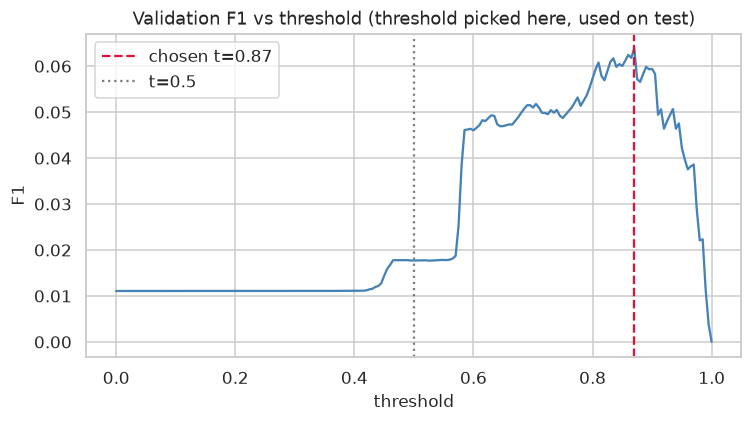

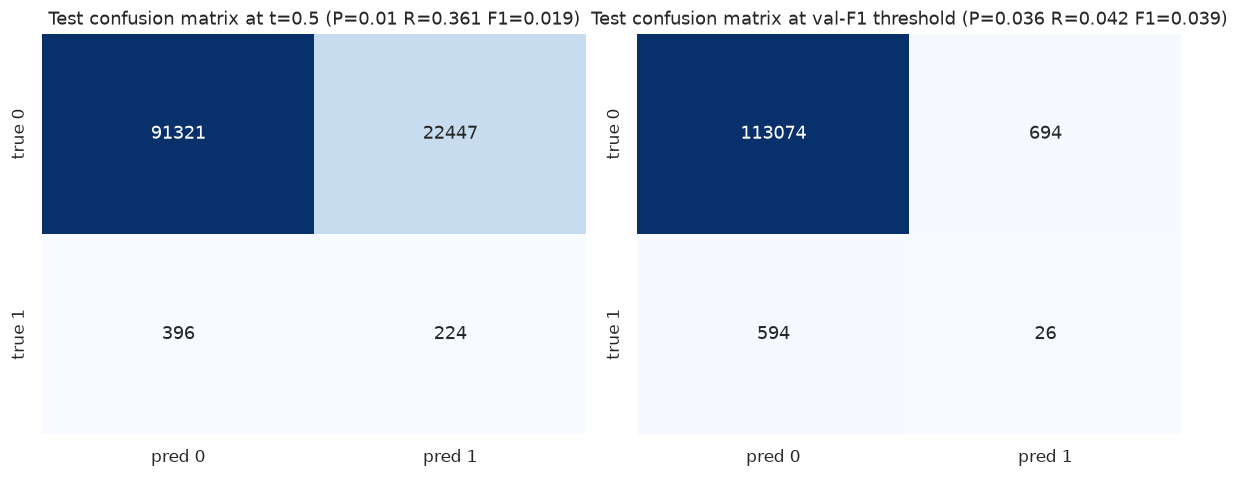

In [5]:
yv, sv = scores["val"]
grid = np.linspace(0.0, 1.0, 201)
f1s = [f1_score(yv, sv >= t, zero_division=0) for t in grid]
thr = saved["operating_threshold_from_val"]["threshold"]
print("val F1 at 0.5:", round(f1_score(yv, sv >= 0.5), 4),
      "| val F1 at chosen threshold:", round(max(f1s), 4))
assert abs(thr - float(grid[int(np.argmax(f1s))])) < 1e-9
print("chosen threshold", round(thr, 3), "reproduced from val grid")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, f1s, color="steelblue")
ax.axvline(thr, color="crimson", linestyle="--", label="chosen t=" + str(round(thr, 3)))
ax.axvline(0.5, color="grey", linestyle=":", label="t=0.5")
ax.set_title("Validation F1 vs threshold (threshold picked here, used on test)")
ax.set_xlabel("threshold")
ax.set_ylabel("F1")
ax.legend()
plt.tight_layout()
plt.show()

yt, st = scores["test"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, t, ttl in zip(axes, [0.5, thr], ["Test confusion matrix at t=0.5",
                                         "Test confusion matrix at val-F1 threshold"]):
    cm = confusion_matrix(yt, (st >= t).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    m = saved["test_at_0.5"] if t == 0.5 else saved["test_at_f1_threshold"]
    ax.set_title(ttl + " (P=" + str(round(m["precision"], 3)) +
                 " R=" + str(round(m["recall"], 3)) + " F1=" + str(round(m["f1"], 3)) + ")")
plt.tight_layout()
plt.show()

## 5. Precision at top-k and lift
For a fixed outreach budget, what matters is precision among the top-scored
rows. Lift = precision@k / prevalence (1.0 = random targeting). Recomputed and
checked against JSON.

top 1%: k = 1143 | P = 0.0359 | R = 0.0661 | lift = 6.62 x | verified
top 5%: k = 5719 | P = 0.0185 | R = 0.171 | lift = 3.42 x | verified
top 10%: k = 11438 | P = 0.0137 | R = 0.2532 | lift = 2.53 x | verified


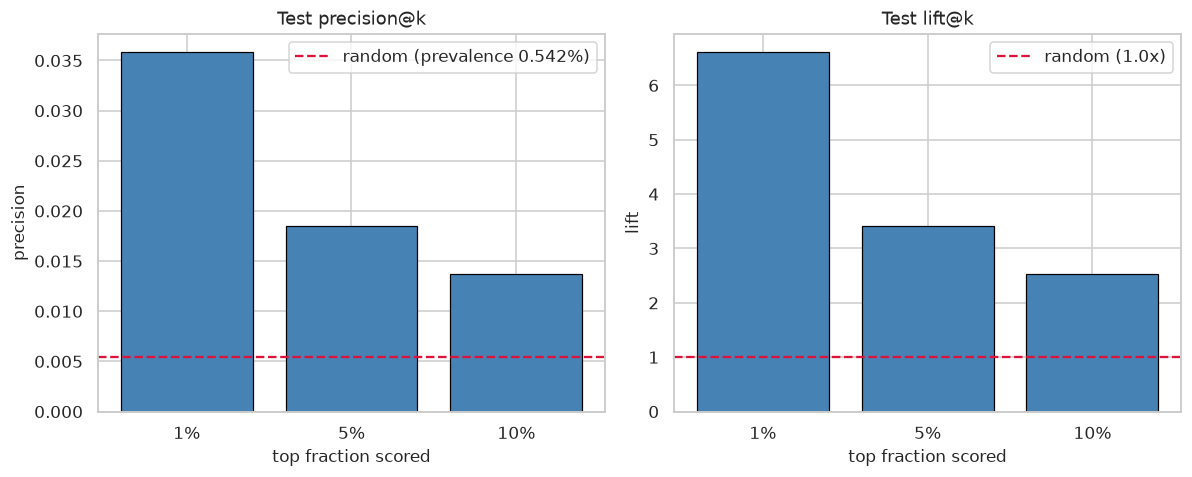

In [6]:
yt, st = scores["test"]
order = np.argsort(-st, kind="stable")
ranked = yt[order]
prev = yt.mean()
for row in saved["test_top_k"]:
    k = row["k"]
    tp = int(ranked[:k].sum())
    assert abs(tp / k - row["precision"]) < 1e-9 and abs(tp / yt.sum() - row["recall"]) < 1e-9
    print("top", str(int(100 * row["frac"])) + "%: k =", k,
          "| P =", round(row["precision"], 4), "| R =", round(row["recall"], 4),
          "| lift =", round(row["lift"], 2), "x | verified")
tab = pd.DataFrame(saved["test_top_k"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar([str(int(100 * f)) + "%" for f in tab["frac"]], tab["precision"],
            color="steelblue", edgecolor="black", linewidth=0.8)
axes[0].axhline(prev, color="crimson", linestyle="--",
                label="random (prevalence " + str(round(100 * prev, 3)) + "%)")
axes[0].set_title("Test precision@k")
axes[0].set_xlabel("top fraction scored")
axes[0].set_ylabel("precision")
axes[0].legend()
axes[1].bar([str(int(100 * f)) + "%" for f in tab["frac"]], tab["lift"],
            color="steelblue", edgecolor="black", linewidth=0.8)
axes[1].axhline(1.0, color="crimson", linestyle="--", label="random (1.0x)")
axes[1].set_title("Test lift@k")
axes[1].set_xlabel("top fraction scored")
axes[1].set_ylabel("lift")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Calibration
`class_weight="balanced"` deliberately distorts probabilities to help ranking,
so calibration must be checked, not assumed. Quantile-binned curve on test
(equal-count bins, so each point is equally supported) plus Brier score.
A perfectly calibrated model follows the diagonal.

calibration points match JSON | test Brier: 0.22787
prevalence-only Brier: 0.00539


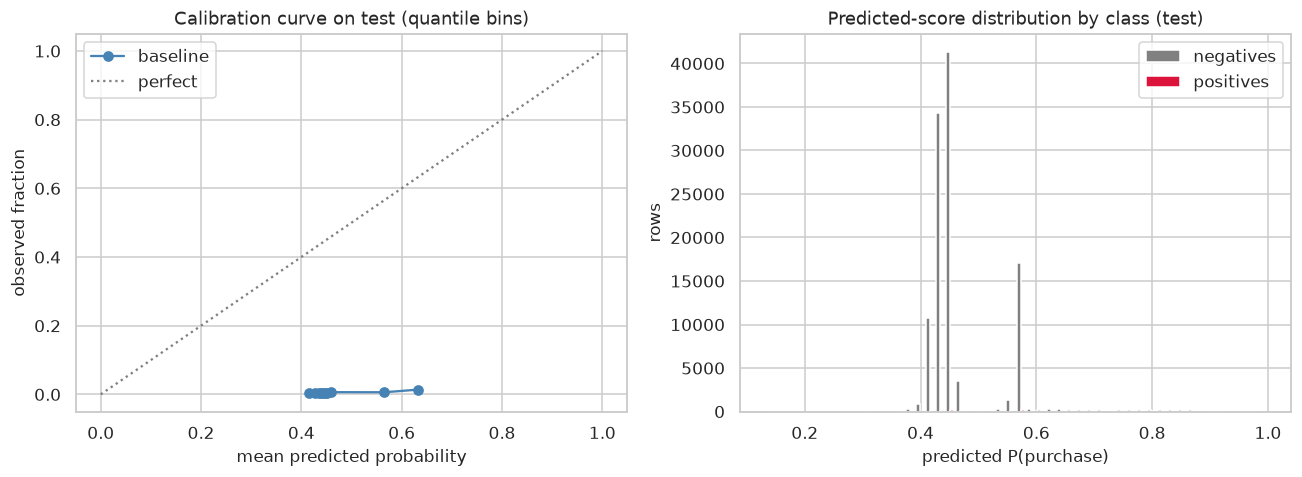

In [7]:
from sklearn.calibration import calibration_curve
yt, st = scores["test"]
pt, pp = calibration_curve(yt, st, n_bins=10, strategy="quantile")
js = saved["test_calibration_quantile10"]
assert np.allclose(pt, js["prob_true"]) and np.allclose(pp, js["prob_pred"])
print("calibration points match JSON | test Brier:", round(saved["test"]["brier"], 5))
brier_prev = float(np.mean((yt - yt.mean()) ** 2))
print("prevalence-only Brier:", round(brier_prev, 5))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(pp, pt, marker="o", color="steelblue", label="baseline")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle=":", label="perfect")
axes[0].set_title("Calibration curve on test (quantile bins)")
axes[0].set_xlabel("mean predicted probability")
axes[0].set_ylabel("observed fraction")
axes[0].legend()
axes[1].hist([st[yt == 0], st[yt == 1]], bins=50, label=["negatives", "positives"],
             color=["grey", "crimson"])
axes[1].set_title("Predicted-score distribution by class (test)")
axes[1].set_xlabel("predicted P(purchase)")
axes[1].set_ylabel("rows")
axes[1].legend()
plt.tight_layout()
plt.show()

## Explanation (after training — grounded in the numbers above)

### Why chronological splitting was used
A model deployed at the end of March 2018 can only have learned from data up
to then. The split reproduces that constraint: train on snapshots 2017-04-01–
2017-12-01 (140,605 rows), validate on 2018-01-01–2018-03-01 (93,774 rows),
test once on 2018-04-01–2018-06-01 (114,388 rows). A random `train_test_split`
would leak the future into training — later snapshots of the same customers,
and future base rates — producing an optimistic estimate for a model that can
never observe the future in production. Preprocessing (median, scaler) was fit
on train only, and the F1 threshold (0.870) was picked on validation, so the
test numbers are an honest single look. Disclosed, not hidden: 11,631 of
49,961 test customers also appear in train (stacked panel). The split prevents
*future-period* information from training the model; it does not isolate
customers, which matches the intended use (scoring known and new customers
each month).

### Why PR-AUC matters (and accuracy does not)
Test prevalence is 0.54% (620/114,388). The never-purchase rule scores 99.46%
accuracy, so accuracy cannot discriminate models here and was never used.
ROC-AUC (test 0.625) looks almost respectable only because its false-positive
axis is diluted by ~114k correctly-ranked negatives. PR-AUC (test 0.0126 vs a
random-ranking 0.0054) measures what the business actually buys: precision
among the few rows flagged. The operating views say the same — F1 is 0.019 at
t = 0.5 and 0.039 at the validation-chosen threshold; only precision@k/lift
(top-1%: 3.6% precision, 6.6x lift; top-5%: 1.9%, 3.4x; top-10%: 1.4%, 2.5x)
describe a usable targeting rule.

### What the baseline tells us
- **Weak but real ranking signal.** Test PR-AUC ≈ 2.3x random with positive
  lift at every budget — the Phase-3 associations (frequency, recency, repeat
  history) carry into out-of-time ranking, but nothing here is close to
  deployment-grade precision.
- **Coefficients agree with the EDA, associational only.** Spend (+0.51),
  last-gap (+0.24) and 180d count (+0.10) rank highest positive; recency is
  negative (−0.08) as expected. The large negative AOV coefficient (−0.54)
  does not mean "cheaper baskets cause repurchase" — spend and AOV correlate
  at rho ≈ 0.99, so the pair splits one effect across two weights.
  Multicollinearity warning, not a finding.
- **Decay and noise are visible.** Val PR-AUC (0.0206) exceeds test (0.0126)
  while ROC moves the other way (0.597 → 0.625) — with ~500–600 positives per
  period, metric wobble is expected and later work needs temporal robustness,
  not single-split luck.
- **Probabilities are miscalibrated by design.** `class_weight="balanced"`
  pushes scores upward (hence the 0.870 operating threshold); test Brier
  0.228 is far worse than the constant-prevalence 0.0054. Treat outputs as
  rankers, never as stated probabilities, until a calibration-preserving
  imbalance strategy is adopted.
- **The bar for the next phase is frozen:** on this exact test split, beat
  PR-AUC 0.0126 / ROC-AUC 0.625 / lift@5% 3.4x — with the same chronological
  protocol. No advanced models were built here by design.
